# Session / plane ROI SNR metrics

This notebook follows the loading workflow in `data_loader_example.ipynb` and calculates SNR-focused QC metrics for every ROI in one plane:

1. **Robust event SNR**: `(P95(dF/F) - median(dF/F)) / robust fast-residual noise SD`. This is the primary amplitude-to-noise QC metric.
2. **Exceptional-event fitness** adapted from `evaluate_components.py`: the minimum log probability of observing `N` consecutive high samples under a lower-tail noise model. More-negative fitness indicates stronger exceptional events; `exceptional_event_score = -fitness` is provided so larger values indicate stronger events.
3. **Event-triggered dF/F SNR**: the peak of the median event-triggered dF/F transient divided by robust dF/F noise SD.

`GAUSSIAN_SIGMA` is measured in imaging frames, not seconds.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import mesoscope_qc_pipeline as qc
import mesoscope_qc_reports as qcr
from mesoscope_snr import calculate_roi_snr_metrics

# The report module selects the noninteractive Agg backend for PDF files.
# Restore inline rendering for this notebook after importing it.
%matplotlib inline


## Configuration

`SESSION_SOURCE` may be a downloaded local NWB path or an AIND processed-session S3 path. Set `MAX_FRAMES = None` to calculate metrics from the complete trace. Using a frame limit changes percentile, noise, and exceptional-event estimates.

### Interpretation notes

- **Robust event SNR** asks whether high dF/F fluctuations are large relative to fast residual noise.
- **Exceptional-event score** asks whether the trace contains at least one sustained positive run that is unlikely under a baseline-noise model.
- **Event-triggered dF/F SNR** asks whether extracted OASIS events are accompanied by a visible fluorescence transient.
- **Event traces:** `event_triggered_dff_snr` requires an event/OASIS time series in the NWB file. If no event series is present, the dF/F-only metrics still run.


In [2]:
SESSION_SOURCE = qcr.DEFAULT_SESSION_SOURCE
PLANE = "VISp_0"
MAX_FRAMES = None

GAUSSIAN_SIGMA = 3.0
CONSECUTIVE_SAMPLES = 5
EXCEPTIONAL_ROBUST_STD = False
EVENT_THRESHOLD = 0.0
BASELINE_BINS = 10
KERNEL_PRE_S = 0.5
KERNEL_POST_S = 2.0
MAX_KERNEL_EVENTS = 500

OUTPUT_DIR = REPO_ROOT / "outputs" / "snr_metrics"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
session = qcr.open_session(SESSION_SOURCE)
try:
    nwb = session["nwb"]
    available_planes = list(session["planes"])
    if PLANE not in available_planes:
        raise KeyError(f"Plane {PLANE!r} not found. Available planes: {available_planes}")

    proc = nwb.processing[PLANE]
    dff_series = qc.get_timeseries_from_proc(
        proc,
        [("dff_timeseries", "dff_timeseries"), ("dff_timeseries",)],
    )
    if dff_series is None:
        raise KeyError(f"No dF/F timeseries found for {PLANE}")

    dff, timestamps = qc.load_timeseries_matrix(dff_series, max_frames=MAX_FRAMES)
    event_series = qc.get_timeseries_from_proc(
        proc,
        [("event_timeseries",), ("events", "event_timeseries")],
    )
    events = None
    if event_series is not None:
        events, event_timestamps = qc.load_timeseries_matrix(event_series, max_frames=MAX_FRAMES)
        if events.shape != dff.shape:
            raise ValueError(f"Event shape {events.shape} does not match dF/F shape {dff.shape}")
    roi_metadata = qc.get_roi_metadata_for_plane(nwb, PLANE, load_masks=False).reset_index(drop=True)
    session_id = getattr(nwb, "session_id", None) or str(SESSION_SOURCE).rstrip("/").split("/")[-1]
finally:
    qcr.close_session(session)

print("Session:", session_id)
print("Plane:", PLANE)
print("dF/F shape (time, ROI):", dff.shape)
print("Events loaded:", events is not None)
print("Duration (s):", float(timestamps[-1] - timestamps[0]) if len(timestamps) > 1 else np.nan)


Session: multiplane-ophys_839909_2026-02-20_12-53-27
Plane: VISp_0
dF/F shape (time, ROI): (46303, 345)
Events loaded: True
Duration (s): 4325.61563


In [4]:
snr_metrics = calculate_roi_snr_metrics(
    dff,
    timestamps=timestamps,
    events=events,
    gaussian_sigma=GAUSSIAN_SIGMA,
    consecutive_samples=CONSECUTIVE_SAMPLES,
    exceptional_robust_std=EXCEPTIONAL_ROBUST_STD,
    event_threshold=EVENT_THRESHOLD,
    baseline_bins=BASELINE_BINS,
    kernel_pre_s=KERNEL_PRE_S,
    kernel_post_s=KERNEL_POST_S,
    max_kernel_events=MAX_KERNEL_EVENTS,
)
roi_snr = roi_metadata.merge(snr_metrics, on="roi_index", how="right")
roi_snr["session_id"] = session_id
roi_snr["plane"] = PLANE
front_columns = ["session_id", "plane"]
roi_snr = roi_snr[front_columns + [c for c in roi_snr.columns if c not in front_columns]]
snr_preview_columns = [
    "session_id",
    "plane",
    "roi_index",
    "soma_probability",
    "robust_event_snr",
    "robust_event_signal_amp",
    "robust_event_noise_sd",
    "exceptional_event_score",
    "event_triggered_dff_snr",
]
roi_snr[[column for column in snr_preview_columns if column in roi_snr]].head()


,session_id,plane,roi_index,soma_probability,robust_event_snr,robust_event_signal_amp,robust_event_noise_sd,exceptional_event_score,event_triggered_dff_snr
0,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,0,0.605588,2.508266,0.103412,0.041228,59.369505,1.903097
1,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,1,0.958772,2.436051,0.122609,0.050331,34.783905,1.770561
2,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,2,0.999195,6.105272,1.249140,0.204600,485.673330,1.527638
3,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,3,0.996062,4.230450,0.336461,0.079533,169.046346,1.625905
4,multiplane-ophys_839909_2026-02-20_12-53-27,VISp_0,4,0.286248,3.664228,1.948021,0.531632,39.709066,1.657921


In [5]:
metric_groups = {
    "dF/F SNR and event-probability metrics": [
        "robust_event_snr",
        "robust_event_signal_amp",
        "robust_event_noise_sd",
        "exceptional_event_fitness",
        "exceptional_event_score",
        "exceptional_event_noise_sd",
    ],
    "Event-triggered SNR metrics": [
        "event_triggered_dff_snr",
        "calcium_kernel_peak_dff",
    ],
}
for group_name, columns in metric_groups.items():
    available = [column for column in columns if column in roi_snr]
    print(f"\n{group_name}")
    display(roi_snr[available].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T)



dF/F SNR and event-probability metrics


,count,mean,std,min,5%,25%,50%,75%,95%,max
robust_event_snr,345.0,3.396984,1.487276,1.953606,2.075760,2.369015,2.863125,3.849413,6.402561,13.087127
robust_event_signal_amp,345.0,0.260564,0.202536,0.072367,0.104633,0.148400,0.198925,0.302870,0.580149,1.948021
robust_event_noise_sd,345.0,0.077752,0.051319,0.028248,0.039739,0.054291,0.065164,0.082409,0.163286,0.531632
exceptional_event_fitness,345.0,-201.123165,229.360500,-1273.979064,-726.461918,-253.318222,-125.173983,-50.034928,-23.443005,-11.989895
exceptional_event_score,345.0,201.123165,229.360500,11.989895,23.443005,50.034928,125.173983,253.318222,726.461918,1273.979064
exceptional_event_noise_sd,345.0,0.074790,0.052607,0.028336,0.036925,0.051098,0.060956,0.077726,0.151981,0.589269



Event-triggered SNR metrics


,count,mean,std,min,5%,25%,50%,75%,95%,max
event_triggered_dff_snr,345.0,3.449480,1.629569,1.438364,1.658743,2.264253,2.808947,4.281691,6.800309,9.24483
calcium_kernel_peak_dff,345.0,0.249558,0.152805,0.070251,0.102278,0.145558,0.210307,0.313292,0.511323,1.53877


## Metric-by-metric SNR plots

Each plot below is intentionally separated so the metric can be interpreted on its own. The formulas match the calculations in `src/mesoscope_snr.py`; the code cell immediately after each markdown cell generates that specific diagnostic plot.


### dF/F signal quality: robust event SNR

Formula:

$$
\mathrm{SNR}_{event} = \frac{P_{95}(\Delta F/F) - P_{50}(\Delta F/F)}{\sigma_{noise}}
$$

with

$$
\sigma_{noise} = 1.4826 \cdot \mathrm{median}\left(|r - \mathrm{median}(r)|\right), \quad r = \Delta F/F - G_{\sigma}(\Delta F/F)
$$

Plain language: this compares a robust high-activity amplitude to fast residual noise. It captures whether the trace has calcium-scale fluctuations that are large relative to noise. Unlike the exceptional-event metric, it summarizes the trace distribution rather than focusing only on the single most improbable run.


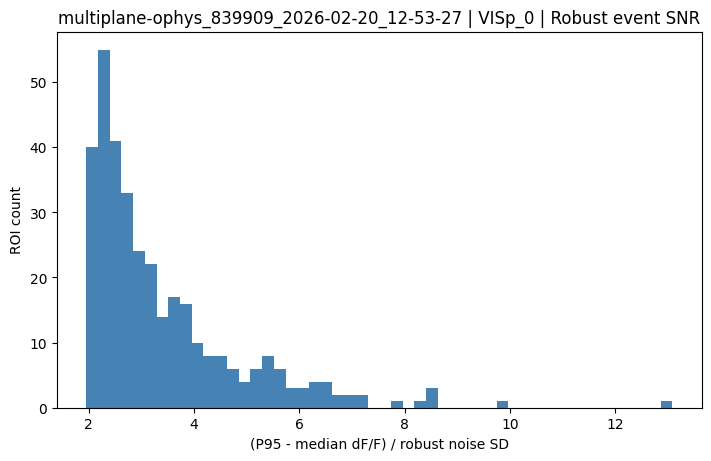

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["robust_event_snr"].dropna(), bins=50, color="steelblue")
ax.set(
    title=f"{session_id} | {PLANE} | Robust event SNR",
    xlabel="(P95 - median dF/F) / robust noise SD",
    ylabel="ROI count",
)
plt.show()


### dF/F signal quality: signal amplitude versus noise

Formulas:

$$
\mathrm{signal\ amplitude} = P_{95}(\Delta F/F) - P_{50}(\Delta F/F)
$$

$$
\mathrm{noise\ SD} = \sigma_{noise}
$$

Plain language: this separates the numerator and denominator of robust event SNR. It is important because the same SNR can arise from a genuinely large event amplitude or from an unusually low noise estimate. This plot helps identify whether high-SNR ROIs are driven by strong calcium signals, low noise, or both.


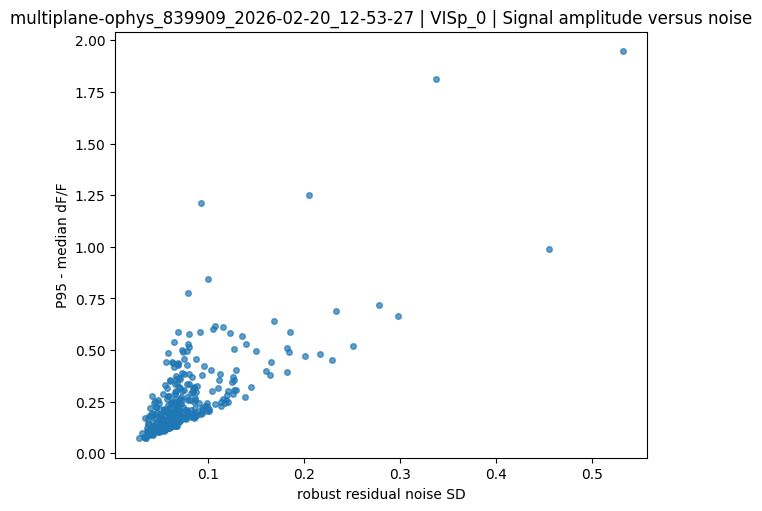

In [7]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(
    roi_snr["robust_event_noise_sd"],
    roi_snr["robust_event_signal_amp"],
    s=16,
    alpha=0.7,
)
ax.set(
    title=f"{session_id} | {PLANE} | Signal amplitude versus noise",
    xlabel="robust residual noise SD",
    ylabel="P95 - median dF/F",
)
plt.show()


### dF/F signal quality: exceptional-event score

Formula:

$$
z_t = \frac{x_t - \hat{x}_{mode}}{3\sigma_{lower}}
$$

$$
\mathrm{fitness} = \min_t \sum_{k=0}^{N-1} \log\left[P(Z > z_{t+k})\right]
$$

$$
\mathrm{exceptional\ event\ score} = -\mathrm{fitness}
$$

Plain language: this asks whether there is at least one sustained positive run that is statistically unlikely under a lower-tail baseline-noise model. It captures the presence of a convincing event even if the rest of the trace is quiet. This is different from robust event SNR, which summarizes broad trace amplitude rather than the strongest unlikely run.


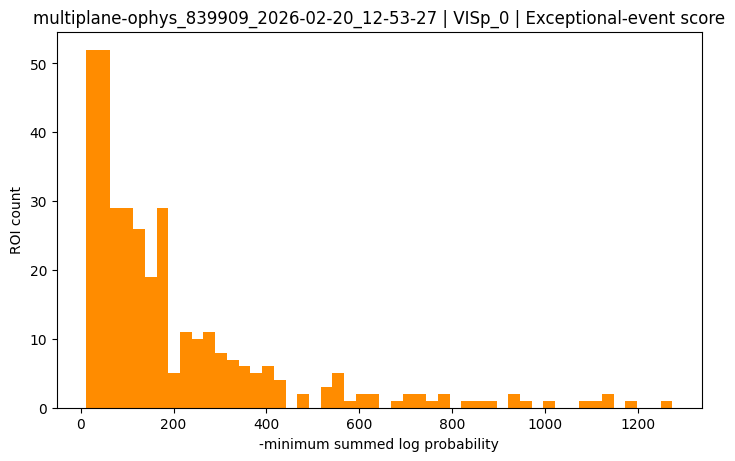

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["exceptional_event_score"].dropna(), bins=50, color="darkorange")
ax.set(
    title=f"{session_id} | {PLANE} | Exceptional-event score",
    xlabel="-minimum summed log probability",
    ylabel="ROI count",
)
plt.show()


### dF/F signal quality: robust SNR versus exceptional-event score

Comparison:

$$
\mathrm{SNR}_{event} \quad \mathrm{versus} \quad -\min_t \sum_{k=0}^{N-1} \log\left[P(Z > z_{t+k})\right]
$$

Plain language: this compares a distribution-wide amplitude-to-noise summary with a single strongest-event improbability score. It is important because these metrics can disagree: one strong artifact can produce a high exceptional-event score, while frequent moderate activity can produce high robust SNR without one dominant event.


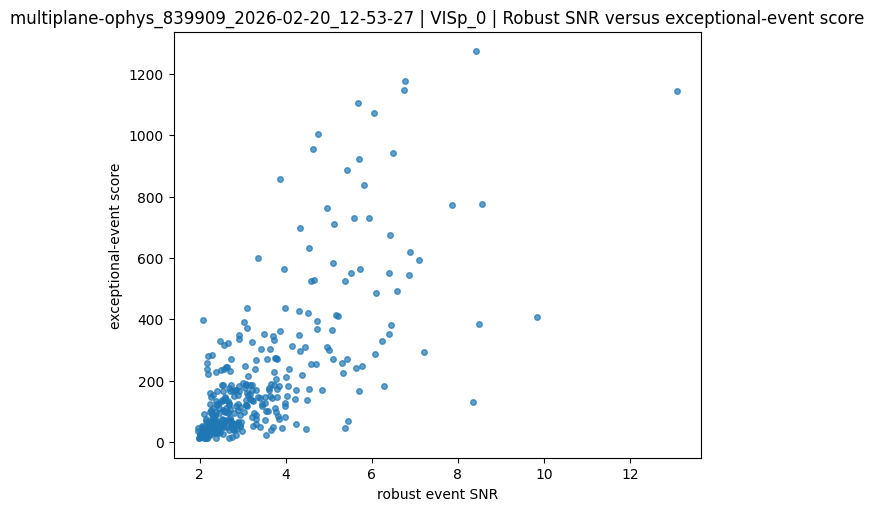

In [9]:
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
ax.scatter(
    roi_snr["robust_event_snr"],
    roi_snr["exceptional_event_score"],
    s=16,
    alpha=0.7,
)
ax.set(
    title=f"{session_id} | {PLANE} | Robust SNR versus exceptional-event score",
    xlabel="robust event SNR",
    ylabel="exceptional-event score",
)
plt.show()


### Event extraction quality: event-triggered dF/F SNR

Formula:

$$
\bar{x}_{event}(\tau) = \mathrm{median}_{events}\left[x(t_{event}+\tau) - \mathrm{median}(x_{pre-event})\right]
$$

$$
\mathrm{event\ triggered\ SNR} = \frac{\max_{\tau \ge 0}\bar{x}_{event}(\tau)}{\sigma_{noise}}
$$

Plain language: this asks whether extracted OASIS events are actually accompanied by a visible calcium transient in dF/F. It captures event-extraction quality, not just trace quality. A high event rate with low event-triggered SNR suggests the event detector may be responding to noise or small fluctuations.


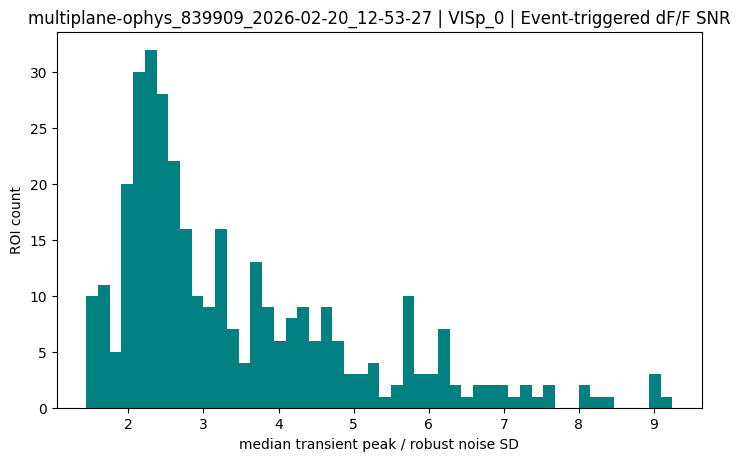

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.hist(roi_snr["event_triggered_dff_snr"].dropna(), bins=50, color="teal")
ax.set(
    title=f"{session_id} | {PLANE} | Event-triggered dF/F SNR",
    xlabel="median transient peak / robust noise SD",
    ylabel="ROI count",
)
plt.show()


In [11]:
ranked = roi_snr.sort_values("robust_event_snr", ascending=False)
rank_columns = [
    "roi_index",
    "soma_probability",
    "robust_event_snr",
    "robust_event_signal_amp",
    "robust_event_noise_sd",
    "exceptional_event_fitness",
    "exceptional_event_score",
    "event_triggered_dff_snr",
]
display(ranked[[column for column in rank_columns if column in ranked]].head(25))


,roi_index,soma_probability,robust_event_snr,robust_event_signal_amp,robust_event_noise_sd,exceptional_event_fitness,exceptional_event_score,event_triggered_dff_snr
153,153,0.029021,13.087127,1.213233,0.092704,-1142.489639,1142.489639,3.740553
287,287,0.999851,9.831788,0.777833,0.079114,-408.732791,408.732791,3.285693
13,13,0.944349,8.567529,0.587289,0.068548,-777.042497,777.042497,1.573196
154,154,0.999998,8.487575,0.843454,0.099375,-383.217085,383.217085,2.153243
80,80,0.999266,8.413885,0.486433,0.057813,-1273.979064,1273.979064,5.924334
207,207,0.048118,8.351869,0.540618,0.064730,-130.322150,130.322150,1.946413
59,59,0.999983,7.864872,0.441820,0.056176,-773.172480,773.172480,6.112110
199,199,0.999266,7.216401,0.577725,0.080057,-293.653453,293.653453,3.973322
242,242,0.999994,7.108980,0.444355,0.062506,-594.527203,594.527203,5.671414
147,147,0.999869,6.894971,0.437781,0.063493,-619.458901,619.458901,6.147030


In [12]:
safe_session = "".join(c if c.isalnum() or c in "._-" else "_" for c in str(session_id))
output_csv = OUTPUT_DIR / f"{safe_session}_{PLANE}_roi_signal_quality_metrics.csv"
roi_snr.to_csv(output_csv, index=False)
print(output_csv)


/storage/home/hcoda1/3/grubin6/openscope-ophys-qc/outputs/snr_metrics/multiplane-ophys_839909_2026-02-20_12-53-27_VISp_0_roi_signal_quality_metrics.csv
